In [2]:
%matplotlib inline

In [65]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
	
image = cv2.imread('resources/eye.png', cv2.IMREAD_UNCHANGED)
image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA)

image = cv2.imread('resources/eye.png', cv2.IMREAD_UNCHANGED)  
gray = cv2.cvtColor(image, cv2.COLOR_BGRA2GRAY) 

In [72]:
def centroid(_img):
    gray_image = cv2.cvtColor(_img, cv2.COLOR_BGRA2GRAY)
    ret, thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY_INV)  # invert to find dark regions
    M = cv2.moments(thresh)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    return (cX, cY)

cn = centroid(image)

def detect_pupil(_img, _centroid):
    img_bgr = cv2.cvtColor(_img, cv2.COLOR_BGRA2BGR)  # drop alpha
    dst = cv2.fastNlMeansDenoisingColored(img_bgr, None, 10, 10, 7, 21)
    blur = cv2.GaussianBlur(dst,(5,5),0)
    inv = cv2.bitwise_not(blur)
    thresh = cv2.cvtColor(inv, cv2.COLOR_BGR2GRAY)
    kernel = np.ones((2,2),np.uint8)
    erosion = cv2.erode(thresh,kernel,iterations = 1)
    ret,thresh1 = cv2.threshold(erosion,210,255,cv2.THRESH_BINARY)
    cnts, hierarchy = cv2.findContours(thresh1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    flag = 10000
    final_cnt = None
    for cnt in cnts:
        (x,y),radius = cv2.minEnclosingCircle(cnt)
        distance = abs(_centroid[0]-x)+abs(_centroid[1]-y)
        if distance < flag :
            flag = distance
            final_cnt = cnt
        else:
            continue
    (x,y),radius = cv2.minEnclosingCircle(final_cnt)
    center = (int(x),int(y))
    radius = int(radius)
    cv2.circle(_img,center,radius,(255,0,0),2)
    
    _pupil = (center[0],center[1],radius)
    return _img

In [70]:
pupil = detect_pupil(image, cn)

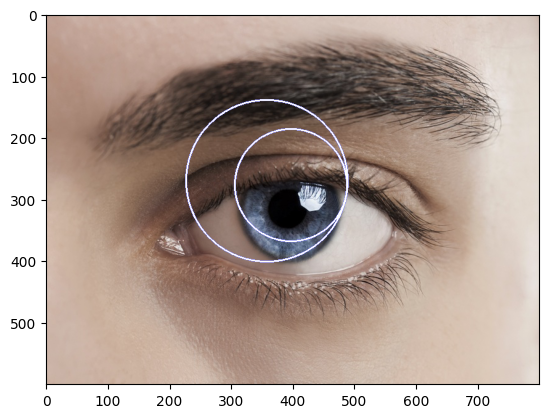

In [73]:
plt.imshow(cv2.cvtColor(pupil, cv2.COLOR_BGRA2RGBA))
plt.show()